In [4]:
import pandas as pd
f = pd.read_csv("../data/frame.csv")
m = pd.read_csv("../data/memory.csv")
print(len(f), len(m))
print(f.columns.tolist())

214583 3938
['sweepId', 'serverId', 'runId', 't', 'load', 'phase', 'liveBullets', 'frameMs', 'terminated', 'playerCount']


In [22]:
lvl = f[(f.load == 16000) & (f.phase == "steady") & (f.sweepId == "frame1")]
print(len(lvl))

2574


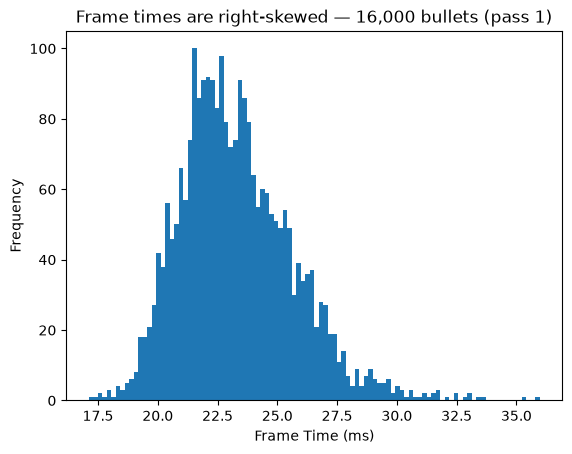

In [23]:
import matplotlib.pyplot as plt

plt.hist(lvl.frameMs, bins = 100)
plt.xlabel("Frame Time (ms)")
plt.ylabel("Frequency")
plt.title("Frame times are right-skewed — 16,000 bullets (pass 1)")
plt.show()

In [36]:
steady1 = f[(f.sweepId == "frame1") & (f.phase == "steady")]
pct1 = steady1.groupby("load").frameMs.quantile([0.5, 0.95, 0.99]).unstack()
pct1.columns = ["p50", "p95", "p99"]
pct1

,p50,p95,p99
load,,,
2000,16.678561,17.196775,18.020621
4000,16.680636,17.229161,17.986044
6000,16.668552,16.981010,18.007092
8000,16.668851,16.980876,18.015986
10000,16.665330,17.385636,19.445459
12000,16.902624,20.378114,23.637925
14000,19.387173,23.697844,28.030263
16000,23.011973,27.380764,30.139379
18000,25.780424,30.675263,35.588142


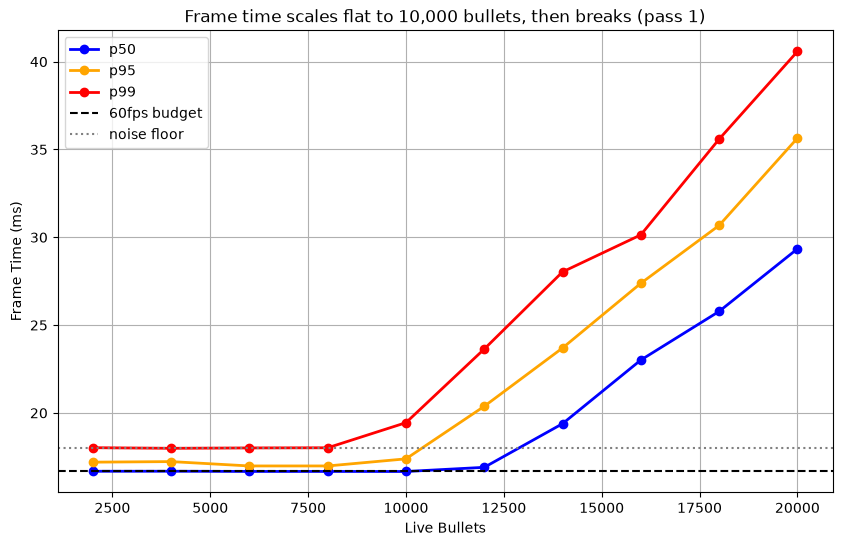

In [37]:
pct1.plot(figsize = (10, 6), marker = "o", linewidth = 2, grid = True, color = ["blue", "orange", "red"], title = "Frame time scales flat to 10,000 bullets, then breaks (pass 1)")
plt.axhline(y = 16.67, color = "black", linestyle = "--", label = "60fps budget")
plt.axhline(y = 18, color = "gray", linestyle = ":", label = "noise floor")
plt.xlabel("Live Bullets")
plt.ylabel("Frame Time (ms)")
plt.legend()
plt.show()

p99's idle baseline is ~ 18ms, so a 19ms threshold is used to clear the noise floor that was measured.

In [46]:
print("p99 crosses at", pct1[pct1["p99"] > 19].index[0])
print("p95 crosses at", pct1[pct1["p95"] > 18].index[0])
print("p50 crosses at", pct1[pct1["p50"] > 18].index[0])

p99 crosses at 10000
p95 crosses at 12000
p50 crosses at 14000


Testing to see if Bullet terminations coincide with slower frames. Testing at 12000, when p95 is over the noise floor, and at 6000, when the three percentiles, p50, p95, p99, are all under their respective noise floors.

In [51]:
subset12 = steady1[steady1.load == 12000]
slow = subset12[subset12.frameMs > 18]
fast = subset12[subset12.frameMs <= 18]

print(slow.terminated.mean())
print(fast.terminated.mean())

45.09090909090909
38.77078477078477


In [52]:
subset6 = steady1[steady1.load == 6000]
slow = subset6[subset6.frameMs > 18]
fast = subset6[subset6.frameMs <= 18]

print(slow.terminated.mean())
print(fast.terminated.mean())

19.63157894736842
19.532846715328468


At 12,000 bullets slow frames average 16% more terminations than fast ones (45.1 vs 38.8). At 6,000, below the knee, the difference vanishes (19.63 vs 19.53), so the association only appears once the server is struggling. Direction is not established: terminations may be contributing to frame cost, or a longer frame may simply capture more expiries.